## Random Forest Model on Personal Transaction Data
#### Aleksa Marie Ocampo
#### CS 549 Machine Learning Spring 2026

### Loading Data

In [35]:
# data loading script with test splits
import sys
sys.path.insert(0, "../data")

from data_loading import load_train_test_split
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape) 
print("features:", len(feature_cols))
print("classes:", y_train.nunique())
print(y_train.value_counts())

train: (8644, 12) (8644,)
test:  (2162, 12) (2162,)
features: 12
classes: 5
Category_Label
0    3056
1    2980
3    1864
2     538
4     206
Name: count, dtype: int64


### Random Forest Baseline Model

#### Importing the Model

In [36]:
# BASELINE MODEL:
# import random forest model
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#### Training the Model

In [37]:
# training the model and making predictions
base_rf = RandomForestClassifier(random_state=42)

base_rf.fit(X_train, y_train)
y_pred_base = base_rf.predict(X_test)

#### Baseline Evaluation

In [38]:
# BASELINE EVALUATION
print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))
print(classification_report(y_test, y_pred_base))

Baseline Accuracy: 0.35106382978723405
              precision    recall  f1-score   support

           0       0.39      0.43      0.41       764
           1       0.38      0.42      0.40       745
           2       0.16      0.06      0.09       135
           3       0.27      0.23      0.25       466
           4       0.04      0.02      0.03        52

    accuracy                           0.35      2162
   macro avg       0.25      0.23      0.23      2162
weighted avg       0.34      0.35      0.34      2162



### Baseline Confusion Matrix

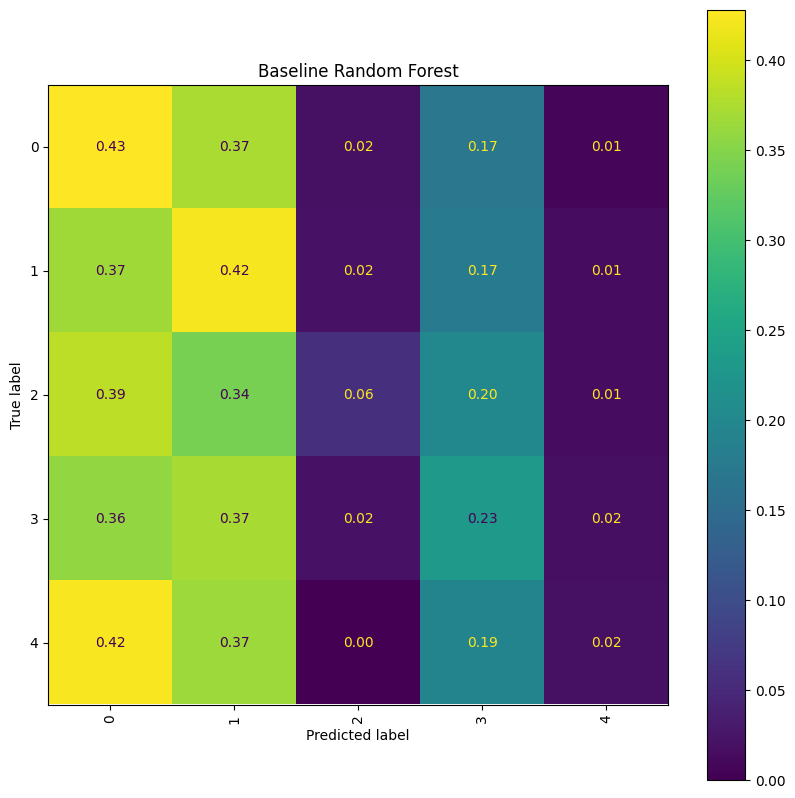

In [39]:
cm = confusion_matrix(y_test, y_pred_base, normalize='true')

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, values_format=".2f")

plt.xticks(rotation=90)
plt.title("Baseline Random Forest")
plt.show()

#### Visualizations

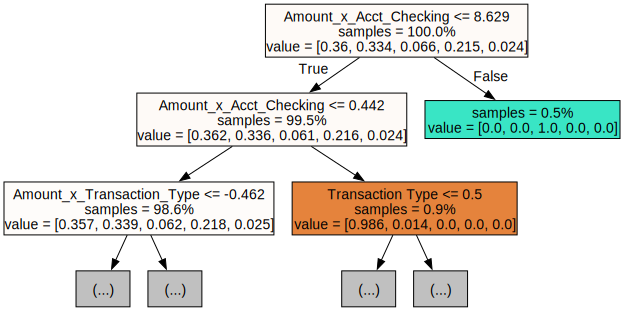

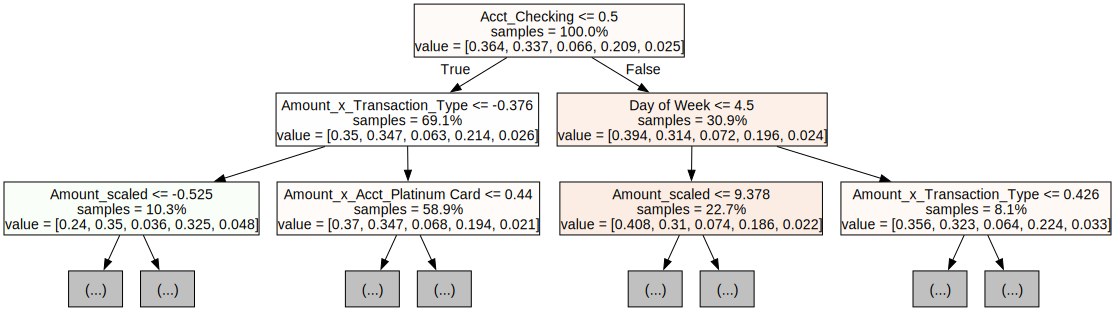

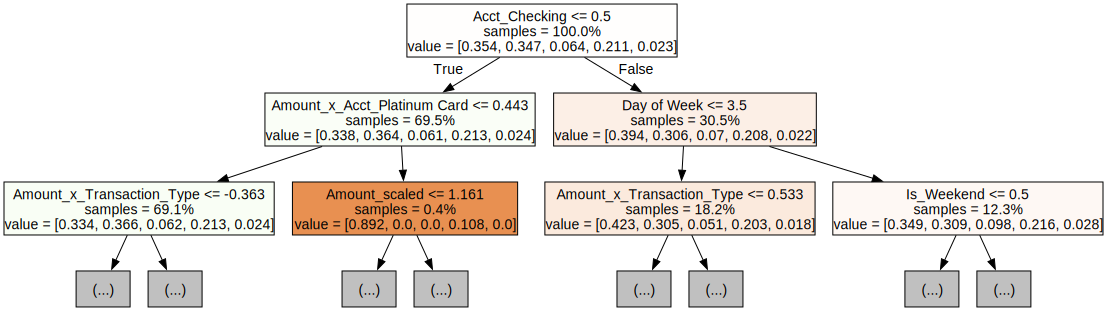

In [40]:
# result visualizations (tree visualization)
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

# first 3 decision trees
for i in range(3):
    tree = base_rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

### Hyperparameter Tuning: Random Search CV

In [41]:
# use randomized search to tune hyperparams
from sklearn.model_selection import cross_val_score, RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestClassifier(random_state=42)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=3,
    scoring="f1_weighted",
    verbose=1,
    n_jobs=2,
    random_state=42
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


/Users/aleksao/CS549/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 30}


### Best Random Forest Model (No class weight)

In [50]:
# no class weight model
best_rf = search.best_estimator_

y_pred_best = best_rf.predict(X_test)

### Tuned Evaluation

In [44]:
print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Tuned Accuracy: 0.3677150786308973
              precision    recall  f1-score   support

           0       0.38      0.48      0.43       764
           1       0.37      0.47      0.41       745
           2       1.00      0.05      0.10       135
           3       0.29      0.15      0.20       466
           4       0.00      0.00      0.00        52

    accuracy                           0.37      2162
   macro avg       0.41      0.23      0.23      2162
weighted avg       0.39      0.37      0.34      2162



/Users/aleksao/CS549/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aleksao/CS549/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aleksao/CS549/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


#### Tuned Confusion Matrix

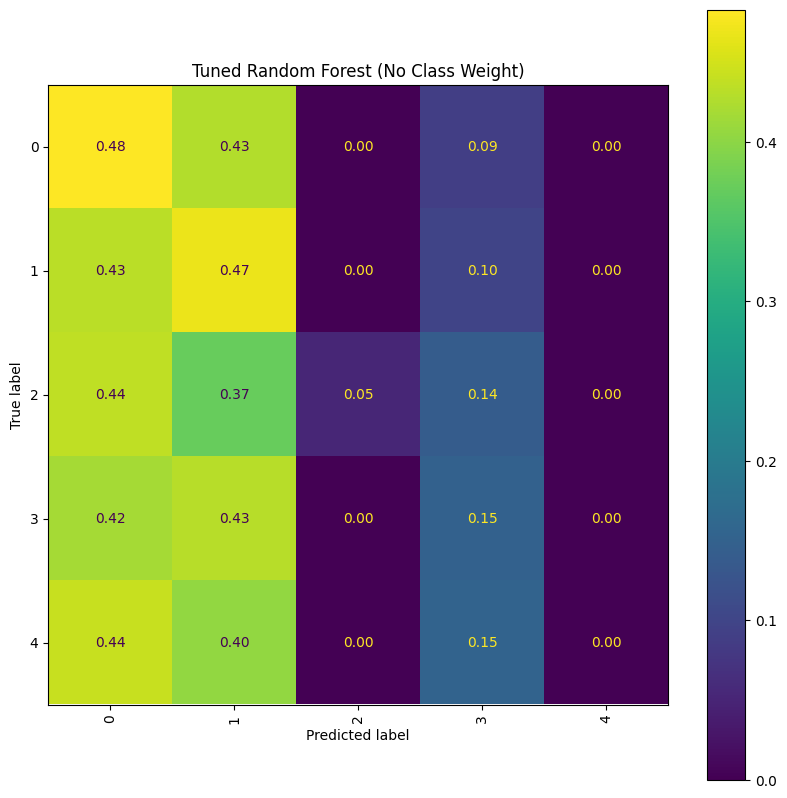

In [45]:
cm = confusion_matrix(y_test, y_pred_best, normalize='true')

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, values_format=".2f")

plt.xticks(rotation=90)
plt.title("Tuned Random Forest (No Class Weight)")
plt.show()

### Balanced Random Forest Model

#### Balanced Model Training

In [46]:
# balanced model
balanced_rf = RandomForestClassifier(
    **search.best_params_,
    class_weight="balanced",
    random_state=42
)

balanced_rf.fit(X_train, y_train)
y_pred_bal = balanced_rf.predict(X_test)

#### Balanced Evaluation

In [47]:
print("Balanced Accuracy:", accuracy_score(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))

Balanced Accuracy: 0.32192414431082333
              precision    recall  f1-score   support

           0       0.39      0.35      0.37       764
           1       0.38      0.36      0.37       745
           2       0.11      0.13      0.12       135
           3       0.26      0.29      0.27       466
           4       0.03      0.06      0.04        52

    accuracy                           0.32      2162
   macro avg       0.24      0.24      0.24      2162
weighted avg       0.33      0.32      0.33      2162



#### Balanced Confusion Matrix

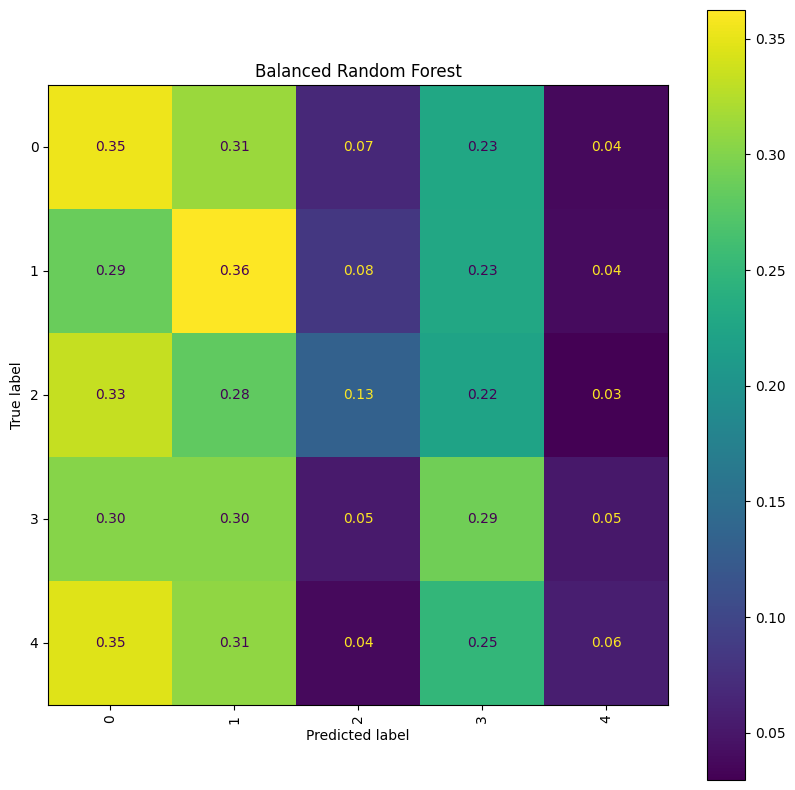

In [48]:
cm = confusion_matrix(y_test, y_pred_bal, normalize='true')

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, values_format=".2f")

plt.xticks(rotation=90)
plt.title("Balanced Random Forest")
plt.show()

### Random Forest Feature Importance

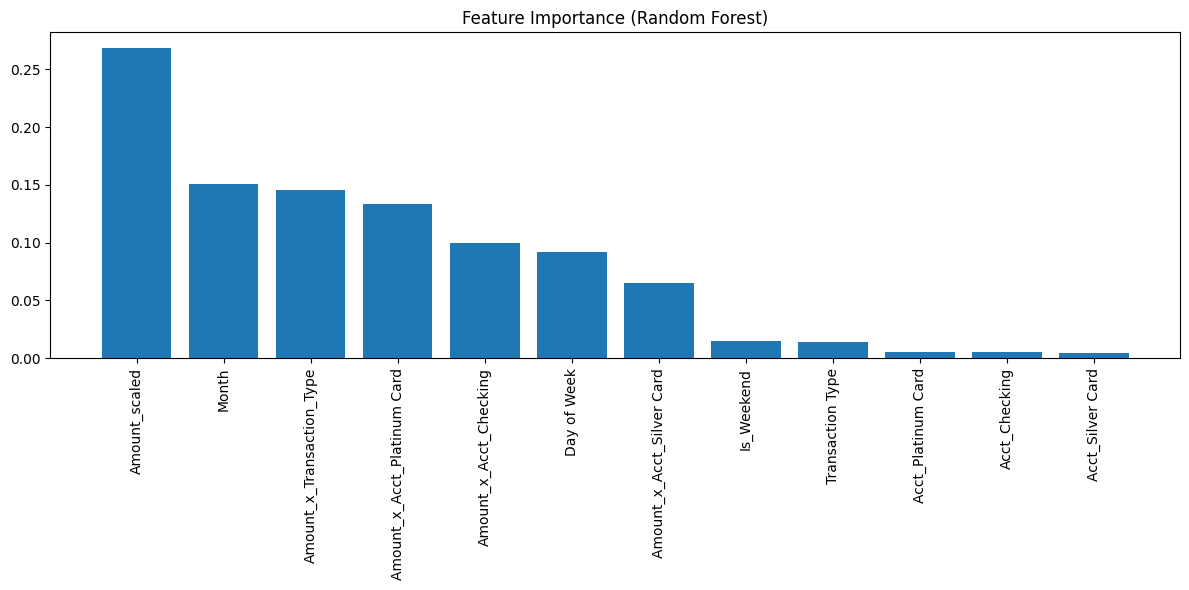

In [49]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X_train.columns[indices], rotation=90)
plt.tight_layout()
plt.show()